```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [1]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
dotenv.load_dotenv('../.env')

True

In [3]:
BASE_DIR = os.getenv('ECG_DIR')
HEA_DIR = os.path.join(BASE_DIR,
                       'physionet_classification_challenge',
                       'training',
                       'ptb', 
                       'g1')

SAMPLE_RATE = 500

In [4]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [23]:
ecg_path = '/media/bramiozo/DATA-FAST/ecg/physionet_classification_challenge/training/ptb/g1/S0513' # hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
record = wfdb.rdrecord(ecg_path)
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [24]:
record.__dict__['comments']

['Age: 55', 'Sex: Male', 'Dx: 164865005', 'Rx: Unknown', 'Hx: Unknown']

In [25]:
re_age = re.compile(r'Age:\s?(\d+)') 
re_sex = re.compile(r'Sex:\s?(\w+)')
re_diagnosis = re.compile(r'(Dx|Diagnosis):\s?([0-9]+)', re.IGNORECASE)

age  = int(re.findall(re_age, meta_str)[0])
sex = re.findall(re_sex, meta_str)[0]
diagnosis = re.findall(re_diagnosis, meta_str)[0][1]

print(f"Age:{age},\nSex:{sex},\nDiagnosis:{diagnosis}")

print(ecg_path, meta_str)

Age:55,
Sex:Male,
Diagnosis:164865005
/media/bramiozo/DATA-FAST/ecg/physionet_classification_challenge/training/ptb/g1/S0513 Age: 55,Sex: Male,Dx: 164865005,Rx: Unknown,Hx: Unknown


In [26]:
wfdb.rdrecord(ecg_path).fs

1000

In [27]:
tmp = wfdb.rdsamp(ecg_path)[0]

In [28]:
tdf = pd.DataFrame(tmp, columns=band_names)
tdf['age'] = age
tdf['sex'] = sex
tdf['diagnosis'] = diagnosis
tdf['segment'] = hea

In [29]:
band_names

['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [30]:
BAND = 'II'

In [31]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

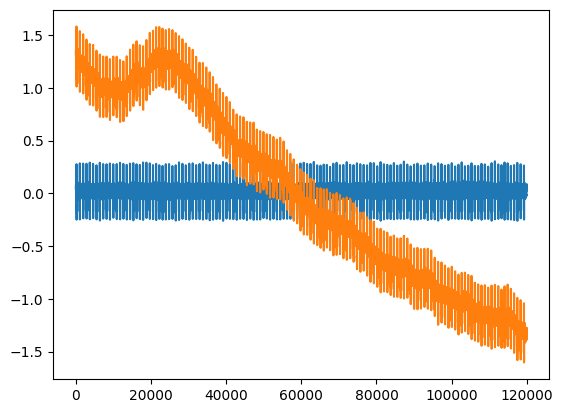

In [34]:
filtered_signal = nk.signal_filter(tdf[BAND], sampling_rate=SAMPLE_RATE, lowcut=0.5, highcut=40, order=2)
plt.plot(filtered_signal)
plt.plot(tdf[BAND])

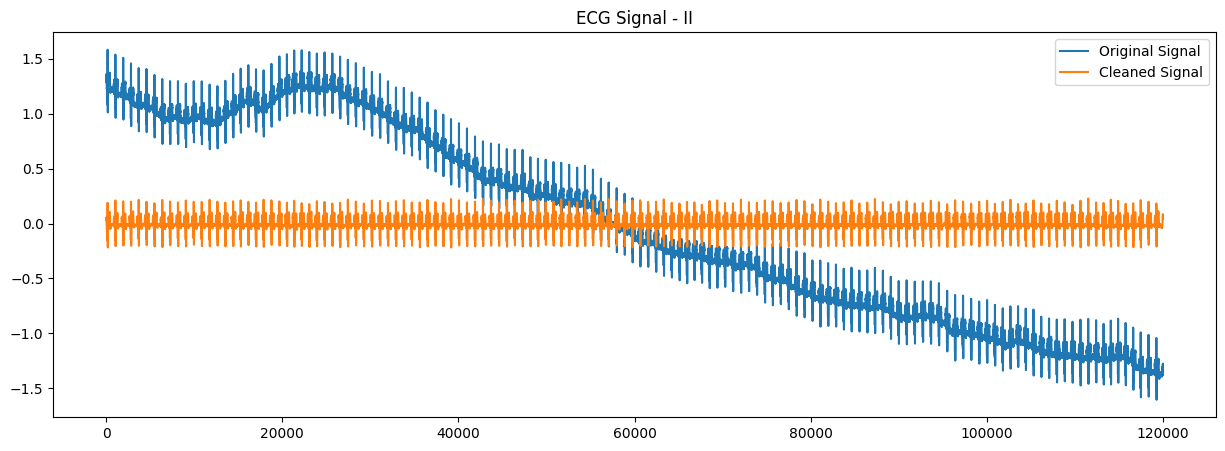

In [33]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [35]:
_, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False)

peak_features_nonlinear = nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'], 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False)

peak_features_frequency = nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True)
                                        

In [36]:
nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, normalize=True).to_dict(orient='index')[0]                                        

{'HRV_ULF': nan,
 'HRV_VLF': 0.0041101968284834286,
 'HRV_LF': 0.022037742579111765,
 'HRV_HF': 0.05162871401325825,
 'HRV_VHF': 0.00655154782304313,
 'HRV_TP': 0.08432820124389656,
 'HRV_LFHF': 0.4268505036451707,
 'HRV_LFn': 0.2613330090532056,
 'HRV_HFn': 0.6122354473556969,
 'HRV_LnHF': -2.963677288143214}

In [37]:
nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'],sampling_rate=SAMPLE_RATE,show=False).to_dict(orient='index')[0]


{'HRV_SD1': 356.04809970913715,
 'HRV_SD2': 468.0651856168937,
 'HRV_SD1SD2': 0.7606805860595637,
 'HRV_S': 523558.1020649621,
 'HRV_CSI': 1.314612227952531,
 'HRV_CVI': 6.4259349946509685,
 'HRV_CSI_Modified': 2461.2968659633584,
 'HRV_PIP': 0.5231788079470199,
 'HRV_IALS': 0.5238095238095238,
 'HRV_PSS': 0.8181818181818182,
 'HRV_PAS': 0.09523809523809523,
 'HRV_GI': 50.01896993265673,
 'HRV_SI': 52.42726577641751,
 'HRV_AI': 47.62740660618684,
 'HRV_PI': 42.857142857142854,
 'HRV_C1d': 0.3581458568393662,
 'HRV_C1a': 0.6418541431606337,
 'HRV_SD1d': 213.07801766193117,
 'HRV_SD1a': 285.2507903982367,
 'HRV_C2d': 0.6341243914537974,
 'HRV_C2a': 0.3658756085462025,
 'HRV_SD2d': 372.7293303556651,
 'HRV_SD2a': 283.12164219500187,
 'HRV_Cd': 0.5329668497128565,
 'HRV_Ca': 0.4670331502871436,
 'HRV_SDNNd': 303.58639241418643,
 'HRV_SDNNa': 284.1882102603954,
 'HRV_DFA_alpha1': 0.8294407804335384,
 'HRV_MFDFA_alpha1_Width': 1.6324694292679613,
 'HRV_MFDFA_alpha1_Peak': 1.949198117403351,


In [38]:
nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE).to_dict(orient='index')[0]

{'HRV_MeanNN': 1577.4437086092714,
 'HRV_SDNN': 414.7768015975434,
 'HRV_SDANN1': 143.72189516511682,
 'HRV_SDNNI1': 381.2157503011216,
 'HRV_SDANN2': nan,
 'HRV_SDNNI2': nan,
 'HRV_SDANN5': nan,
 'HRV_SDNNI5': nan,
 'HRV_RMSSD': 501.84682922182543,
 'HRV_SDSD': 503.52805146582983,
 'HRV_CVNN': 0.262942379074322,
 'HRV_CVSD': 0.31813929491295184,
 'HRV_MedianNN': 1770.0,
 'HRV_MadNN': 59.303999999999995,
 'HRV_MCVNN': 0.033505084745762706,
 'HRV_IQRNN': 113.0,
 'HRV_SDRMSSD': 0.8265007915676289,
 'HRV_Prc20NN': 1308.0,
 'HRV_Prc80NN': 1806.0,
 'HRV_pNN50': 38.41059602649007,
 'HRV_pNN20': 58.94039735099338,
 'HRV_MinNN': 486.0,
 'HRV_MaxNN': 1862.0,
 'HRV_HTI': 11.615384615384615,
 'HRV_TINN': 1351.5625}

In [41]:
signals, _ = nk.ecg_process(cleaned_signal, sampling_rate=1000)
hr_features = nk.ecg_intervalrelated(signals)
hr_features = {k: np.array(v).flatten()[0] for k,v in hr_features.to_dict(orient='index')[0].items()}
hr_features

{'ECG_Rate_Mean': 67.5072619132916,
 'HRV_MeanNN': 888.812030075188,
 'HRV_SDNN': 19.58746908331951,
 'HRV_SDANN1': nan,
 'HRV_SDNNI1': nan,
 'HRV_SDANN2': nan,
 'HRV_SDNNI2': nan,
 'HRV_SDANN5': nan,
 'HRV_SDNNI5': nan,
 'HRV_RMSSD': 14.286569238486216,
 'HRV_SDSD': 14.340962201122927,
 'HRV_CVNN': 0.022037808243507387,
 'HRV_CVSD': 0.016073780231437306,
 'HRV_MedianNN': 892.0,
 'HRV_MadNN': 16.3086,
 'HRV_MCVNN': 0.018283183856502242,
 'HRV_IQRNN': 22.0,
 'HRV_SDRMSSD': 1.3710407835740817,
 'HRV_Prc20NN': 875.0,
 'HRV_Prc80NN': 905.0,
 'HRV_pNN50': 0.7518796992481203,
 'HRV_pNN20': 14.285714285714285,
 'HRV_MinNN': 823.0,
 'HRV_MaxNN': 931.0,
 'HRV_HTI': 4.586206896551724,
 'HRV_TINN': 93.75,
 'HRV_ULF': nan,
 'HRV_VLF': nan,
 'HRV_LF': 0.04708961069399273,
 'HRV_HF': 0.013073983870187832,
 'HRV_VHF': 0.0028744989923680632,
 'HRV_TP': 0.06303809355654863,
 'HRV_LFHF': 3.6017797758929158,
 'HRV_LFn': 0.747002455773044,
 'HRV_HFn': 0.20739814820795224,
 'HRV_LnHF': -4.33713098752436,
 

In [ ]:
def band_power(freqs, power, low, high):
    indices = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(power[indices], freqs[indices])

def spectral_edge_freq(freqs, power, percent=95):
    total_power = np.trapz(power, freqs)
    target_power = total_power * percent/100
    cumulative_power = np.cumsum(power) * (freqs[1] - freqs[0])
    idx = np.where(cumulative_power >= target_power)[0][0]
    return freqs[idx]

def spectral_entropy(power):
    power = power[power > 0]  # Remove zero values
    power_normalized = power / np.sum(power)
    entropy = -np.sum(power_normalized * np.log2(power_normalized+1e-10))
    return entropy

def spectral_flatness(power):
    geometric_mean = np.exp(np.mean(np.log(power + 1e-10)))
    arithmetic_mean = np.mean(power)
    return geometric_mean / arithmetic_mean


psd_chars = nk.signal_psd(cleaned_signal, sampling_rate=SAMPLE_RATE, method='welch').values
FREQS = psd_chars[:,0]
POWER = psd_chars[:,1]

# frequency of maximum power
dominant_frequency = FREQS[np.argmax(POWER)]

# Median frequency, frequency that divides the cumulative power spectrum in two equal parts 
total_power = np.trapz(POWER, FREQS)
cumulative_power = np.cumsum(POWER) * (FREQS[1] - FREQS[0])
median_freq_idx = np.where(cumulative_power >= POWER/2)[0][0]
median_freq = FREQS[median_freq_idx]

######
p_wave_band = (0.5, 3)      # P-wave components
qrs_complex_band = (4, 20)   # QRS complex components
t_wave_band = (0.5, 7)      # T-wave components
baseline_band = (0, 0.5)     # Baseline wander
mains_noise_band = (49, 51)  # 50Hz power line interference
low_freq_band = (0.04, 0.15) # low frequency
high_freq_band = (0.15, 0.4) # high frequency

p_wave_band_power = band_power(FREQS, POWER, *p_wave_band) # delta
qrs_complex_band_power = band_power(FREQS, POWER, *qrs_complex_band) # theta
t_wave_band_power = band_power(FREQS, POWER, *t_wave_band) # alpha
baseline_band_power = band_power(FREQS, POWER, *baseline_band) # beta
mains_noise_band_power = band_power(FREQS, POWER, *mains_noise_band) # gamma
noise_band_power = band_power(FREQS, POWER, 40, 100) # noise
lf_power = band_power(FREQS, POWER, *low_freq_band) # low frequency
hf_power = band_power(FREQS, POWER, *high_freq_band) # high frequency
total_power = np.trapz(POWER, FREQS) # total power

# ratio of low frequency to high frequency power
lf_hf_ratio = lf_power / hf_power
# ratio of low frequency to total power
lf_total_ratio = lf_power / total_power
qrs_noise_ratio = qrs_complex_band_power / noise_band_power

#######
_spectral_edge_freq = spectral_edge_freq(FREQS, POWER)

#######
_spectral_entropy = spectral_entropy(POWER)

#######
_spectral_flatness = spectral_flatness(POWER)

#######
spectral_centroid = np.sum(FREQS * POWER) / np.sum(POWER)

In [ ]:
_spectral_edge_freq, _spectral_entropy, _spectral_flatness, spectral_centroid

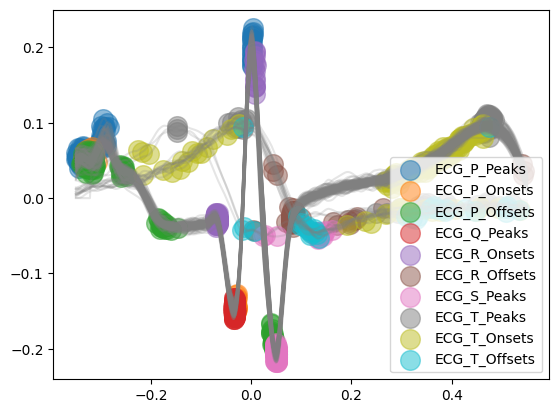

In [40]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="dwt",
                                 show=True,
                                 show_type='all')

In [ ]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

ecg_rsp = nk.ecg_rsp(ecg_rates, method='vangent2019', sampling_rate=SAMPLE_RATE)

In [ ]:
ecg_rates.shape, ecg_rsp.shape, cleaned_signal.shape

In [ ]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=True)

In [5]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import extractor
import wavelets
import ecg

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer

In [7]:
ecgDS = ecg.ECGDataset(df=os.path.join(BASE_DIR,'physionet_classification_challenge', 'training'),
                       label_binarizer=None,
                       augmentations=[],
                       preprocessing=[])

In [8]:
res_dict = defaultdict(dict)
max_count = 100 # for debugging
for i in tqdm(range(len(ecgDS))):
    r = ecgDS[i]
    res_dict[r[0]]={
        'signal': r[2],
        'label': r[3]
    }
    res_dict[r[0]].update(r[4])
    if i > max_count:
        break



  0%|          | 101/43101 [00:02<15:07, 47.40it/s]


In [9]:
_keys = list(res_dict.keys())

In [43]:
res_dict[_keys[0]]

{'signal': tensor([[ 0.7930,  0.7880,  0.7890,  ..., -0.9210, -0.9200, -0.9220],
         [ 1.3150,  1.3070,  1.3030,  ..., -1.3340, -1.3370, -1.3390],
         [ 0.5230,  0.5190,  0.5150,  ..., -0.4130, -0.4170, -0.4170],
         ...,
         [-0.2210, -0.2220, -0.2300,  ...,  0.5000,  0.4990,  0.4970],
         [-0.4530, -0.4550, -0.4590,  ...,  0.3120,  0.3130,  0.3120],
         [-0.6200, -0.6210, -0.6230,  ...,  0.6990,  0.7030,  0.7010]]),
 'label': '164865005',
 'age': 55,
 'sex': 'Male',
 'height': None,
 'weight': None,
 'bmi': None,
 'meds': 'Unknown',
 'history': 'Unknown',
 'fs': 1000,
 'bands': ['I',
  'II',
  'III',
  'aVR',
  'aVL',
  'aVF',
  'V1',
  'V2',
  'V3',
  'V4',
  'V5',
  'V6']}

In [11]:
ecgExtractor = ecg.ECGxtract(sampling_rate=1000)

In [ ]:
ecgExtractor.extract_from_dict(res_dict, SignalCol='signal', FsCol='fs')

  0%|          | 0/102 [00:00<?, ?it/s]

Wavelet features: psd: (17,), wvc: (6,), fcs: (24,)
Wavelet features: psd: (17,), wvc: (6,), fcs: (24,)
Wavelet features: psd: (17,), wvc: (6,), fcs: (24,)
Wavelet features: psd: (17,), wvc: (6,), fcs: (24,)


  0%|          | 0/102 [00:29<?, ?it/s]


KeyboardInterrupt: 